## setup

In [9]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold


In [2]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

net = EEGNetTorch(
    nb_classes=4,
    Chans=22,
    Samples=1001,
    kernLength=32,
    F1=8,
    D=2, F2=16, dropoutRate=0.5,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

x = torch.randn(2, 1, 22, 1001).float().to(device)
print(net(x).shape)

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(


torch.Size([2, 4])


In [4]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np
import torch

def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

In [10]:
import numpy as np

# Load feature arrays
X_list = []
for i in range(1, 10):
    X = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    X = X[:, None, :, :]      # Add channel dimension
    X_list.append(X)

# Combine into one dataset
X = np.concatenate(X_list, axis=0)

print("X shape:", X.shape)


# Load label arrays
y_list = []
for i in range(1, 10):
    y = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")
    y_list.append(y)

# Combine labels
y = np.concatenate(y_list, axis=0)

print("y shape:", y.shape)

X shape: (5184, 1, 22, 1001)
y shape: (5184,)


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()



In [ ]:
batch_size = 32
num_epochs = 100
k = 9

skf = StratifiedKFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

X_cv = X
y_cv = y

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

base_channels = [
    'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3',
    'CP4', 'CPz', 'Cz', 'FC2', 'FC3', 'FC4', 'FCz',
    'P1', 'P2', 'POz', 'Pz', 'C1', 'FC1', 'Fz'
]

## cz, c3, c4

In [ ]:


# Channels to keep
keep_names = ["Cz", "C3", "C4"]
keep = [base_channels.index(ch) for ch in keep_names]

X_cv = X[:, :, keep, :].astype(np.float32)
y_cv = le.fit_transform(y).astype(np.int64)

Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

print("Using channels:", keep_names)
print("X_cv shape:", X_cv.shape)
print("Chans:", Chans, "Samples:", Samples)

Using channels: ['Cz', 'C3', 'C4']
X_cv shape: (5184, 1, 3, 1001)
Chans: 3 Samples: 1001



Fold 1/9

Fold 1 Final Validation -
{'acc': 0.4479166666666667, 'auc': np.float64(0.7133969907407408), 'fmeasure': 0.43948014035874217}

Fold 2/9
Early stopping at epoch 58

Fold 2 Final Validation -
{'acc': 0.4270833333333333, 'auc': np.float64(0.6874919624485596), 'fmeasure': 0.41765397869919285}

Fold 3/9
Early stopping at epoch 48

Fold 3 Final Validation -
{'acc': 0.4045138888888889, 'auc': np.float64(0.6629292052469137), 'fmeasure': 0.39043158153742263}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.4409722222222222, 'auc': np.float64(0.6995764210390947), 'fmeasure': 0.43813226075454337}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.4288194444444444, 'auc': np.float64(0.7010794431584362), 'fmeasure': 0.42063758967991166}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.4375, 'auc': np.float64(0.7039046424897119), 'fmeasure': 0.4304584144988297}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.3993055555555556, 'auc': np.float64(0.6830271026234568), 'fmeasure': 0.3819946787159548}



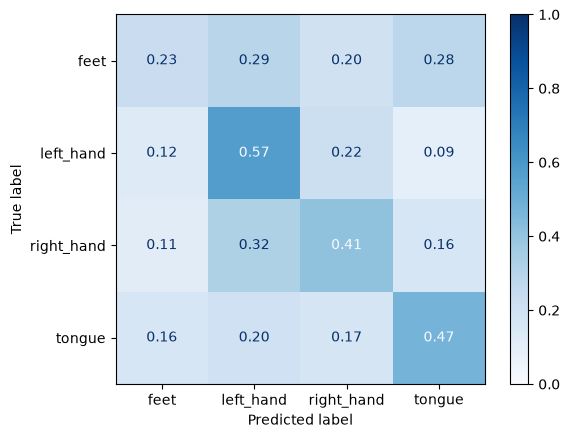

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

fold_results = []
fold_conf_mats = []
num_epochs = 60

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\nFold {fold}/{k}")

    X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
    y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )

    valid_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    net = EEGNetTorch(
        nb_classes=4,
        Chans=Chans,
        Samples=1001,
        kernLength=64,
        F1=32,
        D=4,
        F2=16,
        dropoutRate=0.4854763234903182,
    ).to(device)

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=0.0004102432506048275
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):

        net.train()
        running_loss = 0.0
        n_seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            n_seen += inputs.size(0)

        train_loss = running_loss / n_seen

        net.eval()
        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_seen += inputs.size(0)

        val_loss = val_loss / val_seen

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(net.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    metrics = dict(zip(params, evaluate(net, X_va, y_va, params)))
    fold_results.append(metrics)

    net.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
        outputs = net(X_tensor)
        y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

    cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
    fold_conf_mats.append(cm)

    print(f"\nFold {fold} Final Validation -")
    print(metrics)


print("\n========== Cross-Validation Results ==========")

avg_metrics = {}
for metric in params:
    values = [result[metric] for result in fold_results]
    avg_metrics[metric] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

avg_cm = np.mean(fold_conf_mats, axis=0)

avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    im_kw={"vmin": 0, "vmax": 1},
    values_format=".2f"
)

plt.show()

## cz

In [23]:
# Channels to keep
keep_names = ["Cz"]
keep = [base_channels.index(ch) for ch in keep_names]

X_cv = X[:, :, keep, :].astype(np.float32)
y_cv = le.fit_transform(y).astype(np.int64)

Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

print("Using channels:", keep_names)
print("X_cv shape:", X_cv.shape)
print("Chans:", Chans, "Samples:", Samples)

Using channels: ['Cz']
X_cv shape: (5184, 1, 1, 1001)
Chans: 1 Samples: 1001



Fold 1/9

Fold 1 Final Validation -
{'acc': 0.3177083333333333, 'auc': np.float64(0.595261059670782), 'fmeasure': 0.3161365927747894}

Fold 2/9
Early stopping at epoch 35

Fold 2 Final Validation -
{'acc': 0.3246527777777778, 'auc': np.float64(0.5903018904320987), 'fmeasure': 0.3168712967472883}

Fold 3/9
Early stopping at epoch 26

Fold 3 Final Validation -
{'acc': 0.3159722222222222, 'auc': np.float64(0.5723178690843621), 'fmeasure': 0.30107934419976057}

Fold 4/9
Early stopping at epoch 23

Fold 4 Final Validation -
{'acc': 0.3177083333333333, 'auc': np.float64(0.5733949009773662), 'fmeasure': 0.3103814878478913}

Fold 5/9
Early stopping at epoch 38

Fold 5 Final Validation -
{'acc': 0.2795138888888889, 'auc': np.float64(0.5764572080761317), 'fmeasure': 0.2718031071281285}

Fold 6/9
Early stopping at epoch 31

Fold 6 Final Validation -
{'acc': 0.2899305555555556, 'auc': np.float64(0.5790734310699589), 'fmeasure': 0.28342745548062137}

Fold 7/9
Early stopping at epoch 30

Fold 7 Fin

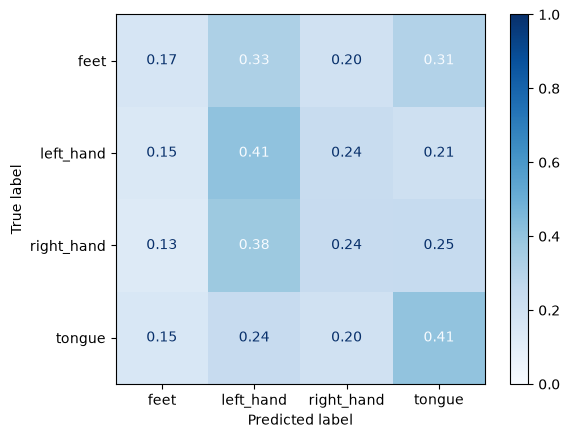

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

fold_results = []
fold_conf_mats = []
num_epochs = 60

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\nFold {fold}/{k}")

    X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
    y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )

    valid_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    net = EEGNetTorch(
        nb_classes=4,
        Chans=Chans,
        Samples=1001,
        kernLength=64,
        F1=32,
        D=4,
        F2=16,
        dropoutRate=0.4854763234903182,
    ).to(device)

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=0.0004102432506048275
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):

        net.train()
        running_loss = 0.0
        n_seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            n_seen += inputs.size(0)

        train_loss = running_loss / n_seen

        net.eval()
        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_seen += inputs.size(0)

        val_loss = val_loss / val_seen

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(net.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    metrics = dict(zip(params, evaluate(net, X_va, y_va, params)))
    fold_results.append(metrics)

    net.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
        outputs = net(X_tensor)
        y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

    cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
    fold_conf_mats.append(cm)

    print(f"\nFold {fold} Final Validation -")
    print(metrics)


print("\n========== Cross-Validation Results ==========")

avg_metrics = {}
for metric in params:
    values = [result[metric] for result in fold_results]
    avg_metrics[metric] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

avg_cm = np.mean(fold_conf_mats, axis=0)

avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    im_kw={"vmin": 0, "vmax": 1},
    values_format=".2f"
)

plt.show()

## FCz Cz CPz

In [25]:
# Channels to keep
keep_names = ["FCz", "Cz", "CPz"]
keep = [base_channels.index(ch) for ch in keep_names]

X_cv = X[:, :, keep, :].astype(np.float32)
y_cv = le.fit_transform(y).astype(np.int64)

Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

print("Using channels:", keep_names)
print("X_cv shape:", X_cv.shape)
print("Chans:", Chans, "Samples:", Samples)

Using channels: ['FCz', 'Cz', 'CPz']
X_cv shape: (5184, 1, 3, 1001)
Chans: 3 Samples: 1001



Fold 1/9

Fold 1 Final Validation -
{'acc': 0.4756944444444444, 'auc': np.float64(0.7607341499485597), 'fmeasure': 0.47316188064629827}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.5052083333333334, 'auc': np.float64(0.7582384902263376), 'fmeasure': 0.4917108977978544}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.4965277777777778, 'auc': np.float64(0.7700376157407408), 'fmeasure': 0.48994901745783376}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.484375, 'auc': np.float64(0.757201646090535), 'fmeasure': 0.4736184697611061}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.5173611111111112, 'auc': np.float64(0.771142779063786), 'fmeasure': 0.5107665087442241}

Fold 6/9
Early stopping at epoch 52

Fold 6 Final Validation -
{'acc': 0.484375, 'auc': np.float64(0.7617549189814814), 'fmeasure': 0.476714638997292}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.4826388888888889, 'auc': np.float64(0.7447635352366255), 'fmeasure': 0.48143728382480194}

Fold 8/9
Early stopping at epoch 52

Fol

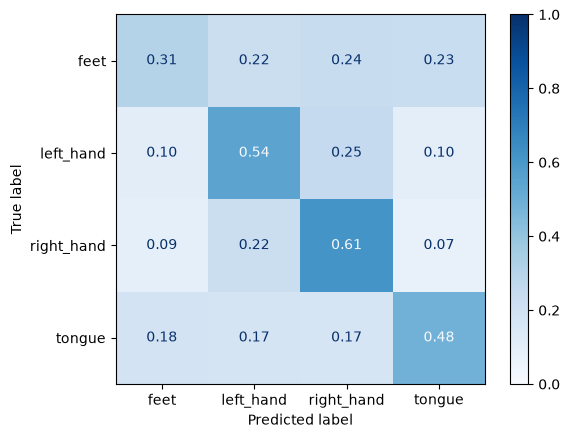

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

fold_results = []
fold_conf_mats = []
num_epochs = 60

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\nFold {fold}/{k}")

    X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
    y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )

    valid_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    net = EEGNetTorch(
        nb_classes=4,
        Chans=Chans,
        Samples=1001,
        kernLength=64,
        F1=32,
        D=4,
        F2=16,
        dropoutRate=0.4854763234903182,
    ).to(device)

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=0.0004102432506048275
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):

        net.train()
        running_loss = 0.0
        n_seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            n_seen += inputs.size(0)

        train_loss = running_loss / n_seen

        net.eval()
        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_seen += inputs.size(0)

        val_loss = val_loss / val_seen

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(net.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    metrics = dict(zip(params, evaluate(net, X_va, y_va, params)))
    fold_results.append(metrics)

    net.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
        outputs = net(X_tensor)
        y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

    cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
    fold_conf_mats.append(cm)

    print(f"\nFold {fold} Final Validation -")
    print(metrics)


print("\n========== Cross-Validation Results ==========")

avg_metrics = {}
for metric in params:
    values = [result[metric] for result in fold_results]
    avg_metrics[metric] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

avg_cm = np.mean(fold_conf_mats, axis=0)

avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    im_kw={"vmin": 0, "vmax": 1},
    values_format=".2f"
)

plt.show()

## remove cz

In [27]:
keep_names = [ch for ch in base_channels if ch != "Cz"]
keep = [base_channels.index(ch) for ch in keep_names]

X_cv = X[:, :, keep, :].astype(np.float32)
y_cv = le.fit_transform(y).astype(np.int64)

Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

print("Using channels:", keep_names)
print("X_cv shape:", X_cv.shape)
print("Chans:", Chans, "Samples:", Samples)

Using channels: ['C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CPz', 'FC2', 'FC3', 'FC4', 'FCz', 'P1', 'P2', 'POz', 'Pz', 'C1', 'FC1', 'Fz']
X_cv shape: (5184, 1, 21, 1001)
Chans: 21 Samples: 1001



Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.8671191808127571), 'fmeasure': 0.6335704806164393}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.8834273726851852), 'fmeasure': 0.6563687940101312}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6614583333333334, 'auc': np.float64(0.8740194187242798), 'fmeasure': 0.6593066233439289}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6232638888888888, 'auc': np.float64(0.878094457304527), 'fmeasure': 0.6205484964994246}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8763342335390947), 'fmeasure': 0.6303139308128791}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8663676697530865), 'fmeasure': 0.6302338006898918}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8654152199074074), 'fmeasure': 0.6182174183313582}

Fold 8/9

Fold 8 Final Validation -
{'acc': 0.58

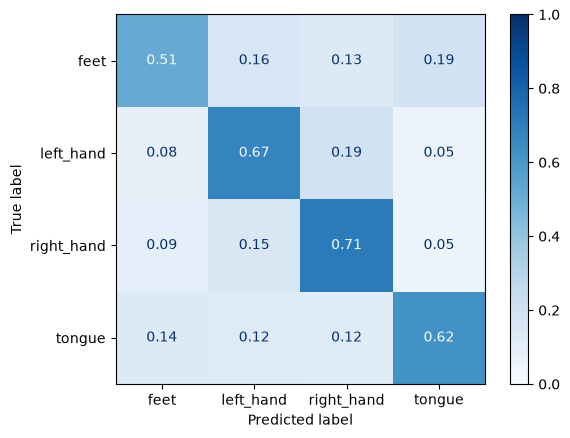

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

fold_results = []
fold_conf_mats = []
num_epochs = 60

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\nFold {fold}/{k}")

    X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
    y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )

    valid_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    net = EEGNetTorch(
        nb_classes=4,
        Chans=Chans,
        Samples=1001,
        kernLength=64,
        F1=32,
        D=4,
        F2=16,
        dropoutRate=0.4854763234903182,
    ).to(device)

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=0.0004102432506048275
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):

        net.train()
        running_loss = 0.0
        n_seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            n_seen += inputs.size(0)

        train_loss = running_loss / n_seen

        net.eval()
        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_seen += inputs.size(0)

        val_loss = val_loss / val_seen

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(net.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    metrics = dict(zip(params, evaluate(net, X_va, y_va, params)))
    fold_results.append(metrics)

    net.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
        outputs = net(X_tensor)
        y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

    cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
    fold_conf_mats.append(cm)

    print(f"\nFold {fold} Final Validation -")
    print(metrics)


print("\n========== Cross-Validation Results ==========")

avg_metrics = {}
for metric in params:
    values = [result[metric] for result in fold_results]
    avg_metrics[metric] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

avg_cm = np.mean(fold_conf_mats, axis=0)

avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    im_kw={"vmin": 0, "vmax": 1},
    values_format=".2f"
)

plt.show()

## sensorimotor

In [29]:
# Channels to keep
keep_names = ["FC3", "FCz", "FC4", "C3", "Cz", "C4", "CP3", "CPz", "CP4"]
keep = [base_channels.index(ch) for ch in keep_names]

X_cv = X[:, :, keep, :].astype(np.float32)
y_cv = le.fit_transform(y).astype(np.int64)

Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

print("Using channels:", keep_names)
print("X_cv shape:", X_cv.shape)
print("Chans:", Chans, "Samples:", Samples)

Using channels: ['FC3', 'FCz', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CPz', 'CP4']
X_cv shape: (5184, 1, 9, 1001)
Chans: 9 Samples: 1001



Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5364583333333334, 'auc': np.float64(0.8239052854938272), 'fmeasure': 0.5330295930201948}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.5815972222222222, 'auc': np.float64(0.8366528420781894), 'fmeasure': 0.5814832936104994}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5642361111111112, 'auc': np.float64(0.8226514274691358), 'fmeasure': 0.5639844700329222}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.8377057613168724), 'fmeasure': 0.6079248459721103}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6041666666666666, 'auc': np.float64(0.8399281442901234), 'fmeasure': 0.6032016520355483}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.5833333333333334, 'auc': np.float64(0.8189863040123457), 'fmeasure': 0.5816343304322473}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5625, 'auc': np.float64(0.8180298353909464), 'fmeasure': 0.5604777794136547}

Fold 8/9

Fold 8 Final Validation -
{'acc': 0.5399305555555

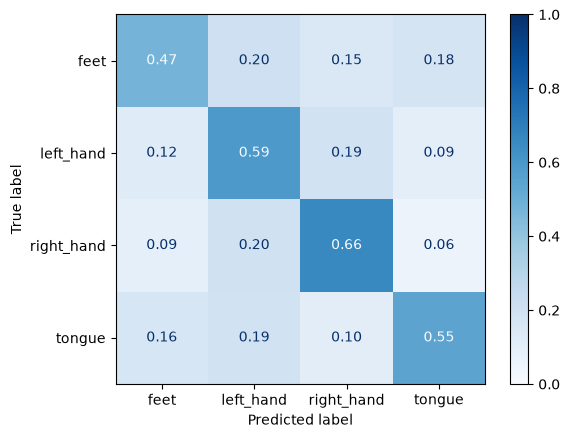

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

fold_results = []
fold_conf_mats = []
num_epochs = 60

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\nFold {fold}/{k}")

    X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
    y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )

    valid_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    net = EEGNetTorch(
        nb_classes=4,
        Chans=Chans,
        Samples=1001,
        kernLength=64,
        F1=32,
        D=4,
        F2=16,
        dropoutRate=0.4854763234903182,
    ).to(device)

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=0.0004102432506048275
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):

        net.train()
        running_loss = 0.0
        n_seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            n_seen += inputs.size(0)

        train_loss = running_loss / n_seen

        net.eval()
        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_seen += inputs.size(0)

        val_loss = val_loss / val_seen

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(net.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    metrics = dict(zip(params, evaluate(net, X_va, y_va, params)))
    fold_results.append(metrics)

    net.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
        outputs = net(X_tensor)
        y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

    cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
    fold_conf_mats.append(cm)

    print(f"\nFold {fold} Final Validation -")
    print(metrics)


print("\n========== Cross-Validation Results ==========")

avg_metrics = {}
for metric in params:
    values = [result[metric] for result in fold_results]
    avg_metrics[metric] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

avg_cm = np.mean(fold_conf_mats, axis=0)

avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    im_kw={"vmin": 0, "vmax": 1},
    values_format=".2f"
)

plt.show()